In [55]:
import numpy as np
from matplotlib import pyplot as plt

In [102]:
# sinc wave with narrowness determined by parameter SincP
#Modified sinc Function for better use
def wsrc(t, SincP):
  ''' This function serves as the sound wave emitted by the source, a sinc function taking in paramters t and SincP, the latter determining the narrowness of the wave'''
  return np.sinc(SincP*t)

# Question 1) Plotting Sinc Pulses:

### Using linspace to plot time along x axis

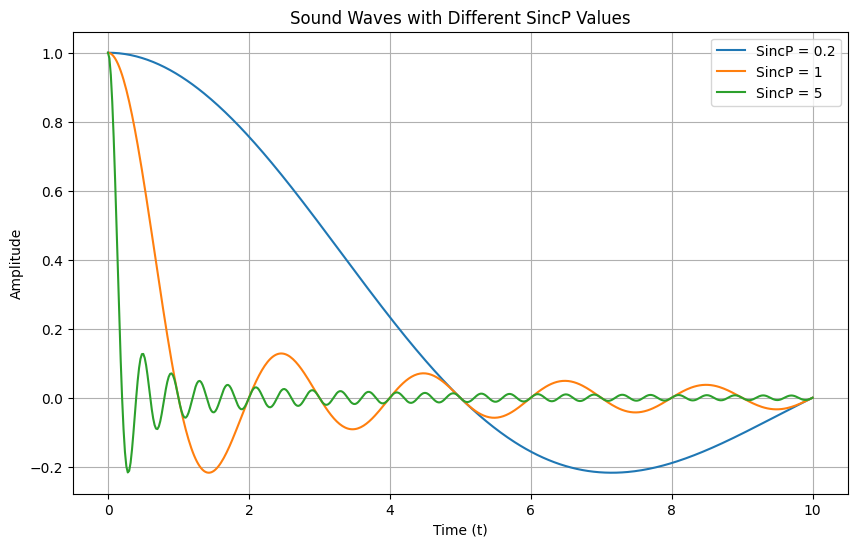

In [65]:

# Define the sinc wave function with SincP as a parameter
def wsrc(t, SincP):
    return np.sinc(SincP * t)

# Generating x values from 2 to 10 with exactly 5 points: [2, 4, 6, 8, 10]
x_values = np.linspace(0, 10, 500)
SincP_values = [0.2, 1, 5]

# Plotting  each sinc curve with a different SincP value from the abve defined list
plt.figure(figsize=(10, 6))
for SincP in SincP_values:
    computed_sine = [wsrc(t, SincP) for t in x_values]
    plt.plot(x_values, computed_sine, label=f'SincP = {SincP}')

plt.title('Sound Waves with Different SincP Values')
plt.xlabel('Time (t)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()



### Doing with other values of Nsamp, C and using sampling times alog x axis:

[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.25, 0.30000000000000004, 0.35000000000000003, 0.4, 0.45, 0.5, 0.55, 0.6000000000000001, 0.65, 0.7000000000000001, 0.75, 0.8, 0.8500000000000001, 0.9, 0.9500000000000001, 1.0, 1.05, 1.1, 1.1500000000000001, 1.2000000000000002, 1.25, 1.3, 1.35, 1.4000000000000001, 1.4500000000000002, 1.5, 1.55, 1.6, 1.6500000000000001, 1.7000000000000002, 1.75, 1.8, 1.85, 1.9000000000000001, 1.9500000000000002, 2.0, 2.0500000000000003, 2.1, 2.15, 2.2, 2.25, 2.3000000000000003, 2.35, 2.4000000000000004, 2.45, 2.5, 2.5500000000000003, 2.6, 2.6500000000000004, 2.7, 2.75, 2.8000000000000003, 2.85, 2.9000000000000004, 2.95, 3.0, 3.0500000000000003, 3.1, 3.1500000000000004, 3.2, 3.25, 3.3000000000000003, 3.35, 3.4000000000000004, 3.45, 3.5, 3.5500000000000003, 3.6, 3.6500000000000004, 3.7, 3.75, 3.8000000000000003, 3.85, 3.9000000000000004, 3.95, 4.0, 4.05, 4.1000000000000005, 4.15, 4.2, 4.25, 4.3, 4.3500000000000005, 4.4, 4.45, 4.5, 4.55, 4.6000000000000005, 4.65, 

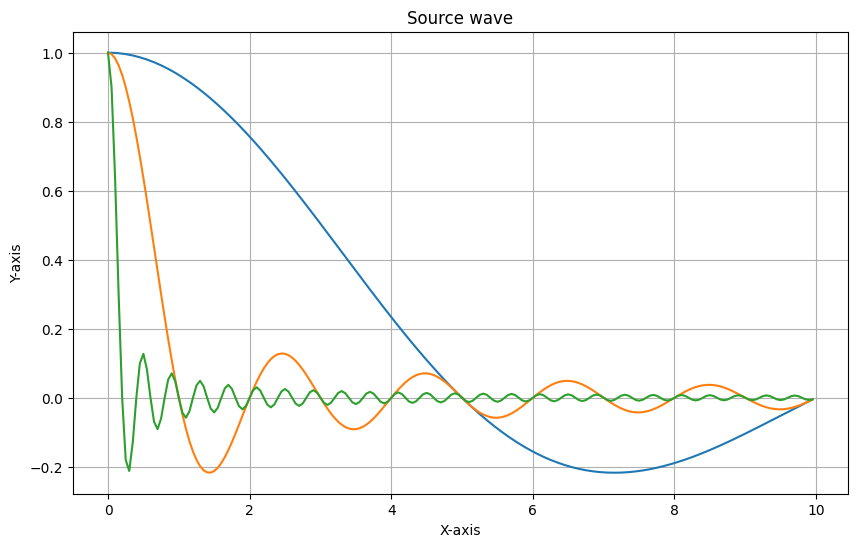

In [103]:

Nsamp = 200
dist_per_samp = 0.1
C = 2
# Different SincP values to visualize how the width changes
SincP_values = [0.2, 1, 5]
samp_time = dist_per_samp/C
sample_times =  [ samp_time * i for i in range(Nsamp) ]
print(sample_times)
plt.figure(figsize=(10, 6))
for SincP in SincP_values:
    computed_sine = [wsrc(t, SincP) for t in sample_times]
    plt.plot(sample_times, computed_sine, label=f'SincP = {SincP}')

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Source wave')
plt.grid()
plt.show()

# Setting Up Mics and Generating Output

## All functions that are used:

In [104]:
def dis(a, b):
    """
    Calculate the Euclidean distance between two points `a` and `b`.

    Parameters:
    a (tuple): Coordinates of the first point (x, y).
    b (tuple): Coordinates of the second point (x, y).

    Returns:
    float: The distance between points `a` and `b`.
    """
    return ((a[0] - b[0])**2 + (a[1] - b[1])**2)**0.5


def ref_dist(src, pt, mic):
    """
    Calculate the total distance a wave travels from the source to a microphone after reflecting off a point.

    Parameters:
    src (tuple): Coordinates of the source (x, y).
    pt (tuple): Coordinates of the reflection point (x, y).
    mic (tuple): Coordinates of the microphone (x, y).

    Returns:
    float: The total distance from the source to the reflection point, then to the microphone.
    """
    d1 = dis(src, pt)  # Distance from source to reflection point
    d2 = dis(mic, pt)  # Distance from reflection point to microphone
    return d1 + d2


def mic_locations(N_mics, pitch):
    """
    Generate the vertical positions of a given number of microphones with a specific spacing between them.

    Parameters:
    N_mics (int): The number of microphones.
    pitch (float): The spacing distance between consecutive microphones.

    Returns:
    list of tuples: List of (x, y) coordinates for each microphone.
    """
    mics = []
    if N_mics % 2 != 0:
        d = pitch
        mics = [(0, y * d) for y in range((N_mics - 1) // 2, -(N_mics + 1) // 2, -1)]
    else:
        d = pitch / 2
        mics = [(0, y * d) for y in range((N_mics - 1), -N_mics, -2)]
    return mics[::-1]


def sample_generator(mic_positions, sample_times, Nsamp, src, obstacle, C, SincP):
    """
    Generate sound wave samples for each microphone based on the source, obstacle, and speed of sound.

    Parameters:
    mic_positions (list of tuples): List of (x, y) coordinates of microphones.
    sample_times (list): List of times at which each microphone samples the wave.
    Nsamp (int): Number of samples to generate.
    src (tuple): Coordinates of the source (x, y).
    obstacle (tuple): Coordinates of the obstacle (x, y).
    C (float): Speed of sound.
    SincP (float): Parameter for wave function.

    Returns:
    list of lists: Sound wave samples for each microphone at each sample time.
    """
    samples = []
    for mic_index, mic_position in enumerate(mic_positions):
        mic_samples = []
        for t in sample_times:
            dist_travelled = ref_dist(src, obstacle, mic_position)
            delay = dist_travelled / C
            wave = wsrc(t - delay, SincP)
            mic_samples.append(wave)
        samples.append(mic_samples)
    return samples


def waveform_plotter(sample_times, samples, mic_positions):
    """
    Plot the sound wave samples at each microphone over time.

    Parameters:
    sample_times (list): List of sample times.
    samples (list of lists): Sound wave samples for each microphone.
    mic_positions (list of tuples): List of (x, y) coordinates of microphones.

    Returns:
    None
    """
    plt.figure(figsize=(10, 6))
    for i, mic_samples in enumerate(samples):
        plt.plot(sample_times, np.array(mic_samples) + mic_positions[i][1], label=f'Mic {i}', linewidth=2)

    plt.xlim(min(sample_times), max(sample_times))
    plt.title('Waveform Samples at Each Microphone')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude + Offset')
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), ncol=2)
    plt.grid()


def heatmap_plotter(samples):
    """
    Create a heatmap to visualize the samples collected from each microphone over time.

    Parameters:
    samples (list of lists): Sound wave samples for each microphone.

    Returns:
    None
    """
    heatmap_data = np.array(samples)
    plt.figure(figsize=(10, 6))
    plt.imshow(heatmap_data, cmap='viridis', origin='lower')


### An output:

In [105]:
# The soud wave is wrsc
Nmics = 64
Nsamp = 200
src = (0, 0)
pitch = 0.1
dist_per_samp = 0.1
C = 2
SincP = 5
obstacle = (3,-1)
samp_time = dist_per_samp/C
mic_positions = mic_locations(Nmics, pitch)
sample_times =  [ samp_time * i for i in range(Nsamp) ] #These are th times at which all mics sample


In [106]:
print(mic_positions, len(mic_positions))
print(len(mic_positions) == Nmics)

[(0, -3.1500000000000004), (0, -3.0500000000000003), (0, -2.95), (0, -2.85), (0, -2.75), (0, -2.6500000000000004), (0, -2.5500000000000003), (0, -2.45), (0, -2.35), (0, -2.25), (0, -2.15), (0, -2.0500000000000003), (0, -1.9500000000000002), (0, -1.85), (0, -1.75), (0, -1.6500000000000001), (0, -1.55), (0, -1.4500000000000002), (0, -1.35), (0, -1.25), (0, -1.1500000000000001), (0, -1.05), (0, -0.9500000000000001), (0, -0.8500000000000001), (0, -0.75), (0, -0.65), (0, -0.55), (0, -0.45), (0, -0.35000000000000003), (0, -0.25), (0, -0.15000000000000002), (0, -0.05), (0, 0.05), (0, 0.15000000000000002), (0, 0.25), (0, 0.35000000000000003), (0, 0.45), (0, 0.55), (0, 0.65), (0, 0.75), (0, 0.8500000000000001), (0, 0.9500000000000001), (0, 1.05), (0, 1.1500000000000001), (0, 1.25), (0, 1.35), (0, 1.4500000000000002), (0, 1.55), (0, 1.6500000000000001), (0, 1.75), (0, 1.85), (0, 1.9500000000000002), (0, 2.0500000000000003), (0, 2.15), (0, 2.25), (0, 2.35), (0, 2.45), (0, 2.5500000000000003), (0,

In [107]:
samples = sample_generator(mic_positions, sample_times, Nsamp, src, obstacle, C, SincP)
print(len(samples), len(samples[0]))

64 200


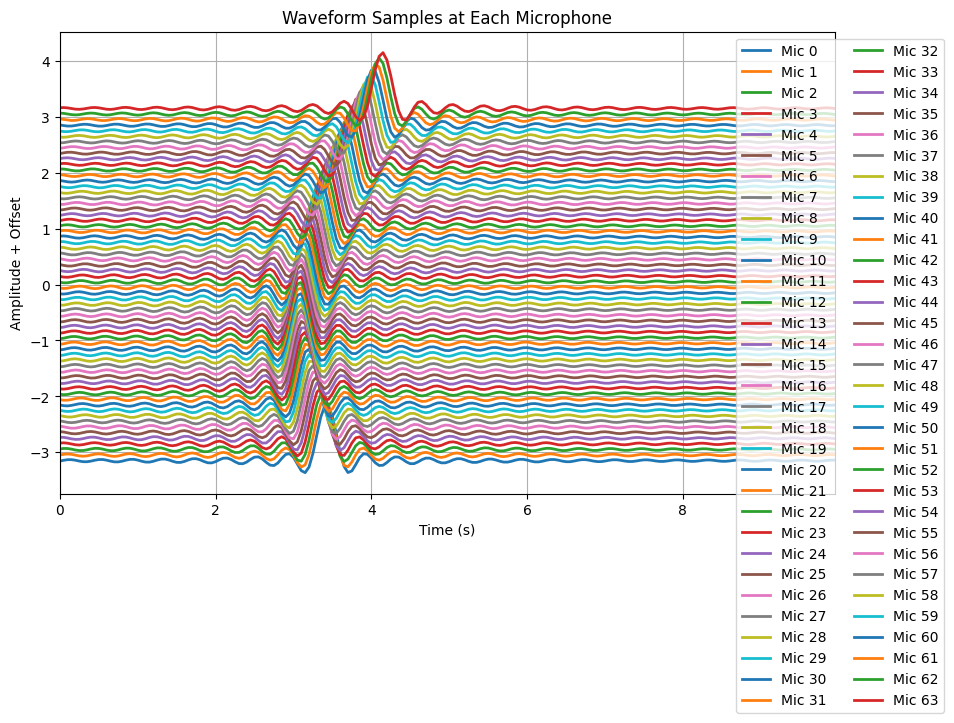

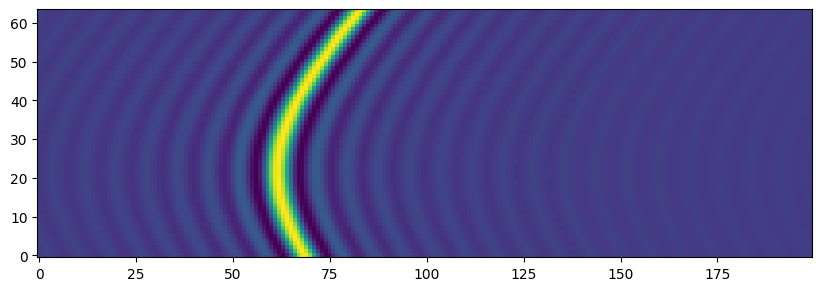

In [108]:
waveform_plotter(sample_times, samples, mic_positions)
heatmap_plotter(samples)

# Delay and Sum Algorithm

In [110]:
import numpy as np

def DAS(Nmics, Nsamp, C, dist_per_samp, src, pitch, mics, samples):
  """
    Perform Delay And Sum (DAS) algorithm for sound source localization by reconstructing an image from microphone recordings.

    The function works as follows:
    1. First, it extracts the Y-coordinates of all microphones and computes the X-coordinates for each sample time.
    2. It calculates the time delay for each microphone and sample using the sound propagation speed (`C`) and the distance
       between the sound source and the microphone. This time delay is then converted to sample indices.
    3. The samples corresponding to each time delay are then summed across all microphones to reconstruct an image of the
       sound source's location, with each grid point representing the accumulated values from the microphones.
    4. The resulting image provides a localization map for the obstacle.

    Parameters:
    Nmics (int): The number of microphones.
    Nsamp (int): The number of samples per microphone.
    C (float): The speed of sound in the medium (in meters per second).
    dist_per_samp (float): The distance between consecutive sample points in meters.
    src (tuple): The coordinates (x, y) of the sound source.
    pitch (float): The distance between consecutive microphones (in meters).
    mics (list of tuples): List of coordinates (x, y) of microphones.
    samples (list of lists): Sound wave sample values from each microphone, one list per microphone.

    Returns:
    numpy.ndarray: A 2D array representing the reconstructed image after applying DAS beamforming, with the grid values
                   indicating the strength of the signal at each reconstructed point.
  """

  Y = [mics[i][1] for i in range(Nmics)]                   # Extract the Y-coordinates of microphones
  X = [samp_time * i  for i in range(Nsamp)]              # Compute X-coordinates (time-based positions for samples)
  reconstructed_image = np.zeros((Nmics, Nsamp))          # Initialize a zero matrix for the reconstructed image
  total_time_delay = []

  for i, y in enumerate(Y):
    for j, x in enumerate(X):
      delay = []                                        # Initialize a list to store delay times for each microphone
      for mic in mics:
        pt = (x *C, y)                                 # Define the current point (x*C, y) where the sample is taken, as we want position we multiply x coordinate with C
        delay.append(ref_dist(src, pt, mic) / C)       # Compute time delay based on the distance from the sound source
      total_time_delay.append(delay)  # Store the delay values for this sample

  total_delay_samples = [[int(time / samp_time) for time in X] for X in total_time_delay]  # Convert delays into sample indices

  grid_values = []

  for lists in total_delay_samples:  # For each coordinates delay samples
    sum = 0
    for l in range(len(samples)):
        if lists[l] < Nsamp:  # Ensure the sample index is within the Nsamp range
          sum += samples[l][lists[l]]  # Add the sample value at the calculated delay index
    grid_values.append(sum)

  reconstructed_image = np.array(grid_values).reshape(Nmics, Nsamp)  # Reshape the summed values into a 2D grid (image)
  return reconstructed_image


## Final Function, That implements all the above functions

In [111]:

def final_reconstructed_image_computer(Nmics, pitch,dist_per_samp,Nsamp, src, obstacle,C, SincP):
  ''' Creates a list of sample times, micrphone positions, and samples corresponding to the wave generted from source at time t = 0, then reconstrcutes using DAS algo'''

  samp_time = dist_per_samp/C
  sample_times =  [ samp_time * i for i in range(Nsamp) ]
  mic_pos = mic_locations(Nmics, pitch)
  samples = sample_generator(mic_pos, sample_times, Nsamp, src, obstacle,C, SincP)
  recons_image = DAS(Nmics, Nsamp, C, dist_per_samp, src, pitch, mic_pos, samples)
  return recons_image




### For Nsamp = 200

In [112]:
# The soud wave is wrsc
Nmics = 64
Nsamp = 200
src = (0, 0)
pitch = 0.1
dist_per_samp = 0.1
C = 2
SincP = 5
obstacle = (3,-1)
samp_time = dist_per_samp/C
mic_positions = mic_locations(Nmics, pitch)
sample_times =  [ samp_time * i for i in range(Nsamp) ] #These are th times at which all mics sample


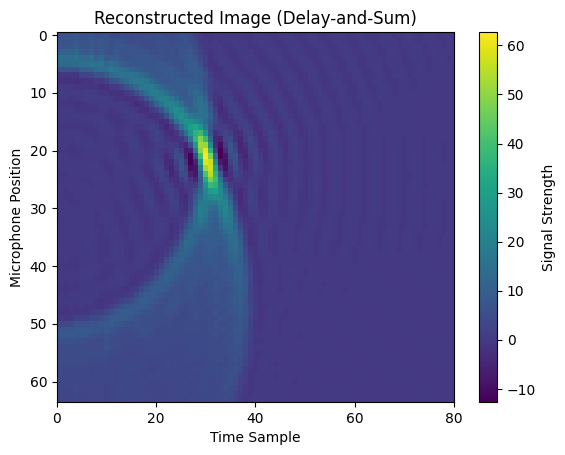

In [117]:
ri = DAS(Nmics, Nsamp, C, dist_per_samp, src, pitch, mic_positions, samples)
plt.imshow(ri, aspect = 'auto')

plt.xticks([0, 20, 40, 60, 80])
plt.xlim(0, 80)  # limiting X values to 80,to get a better view of coordinates
plt.colorbar(label='Signal Strength')
plt.xlabel('Time Sample')
plt.ylabel('Microphone Position')
plt.title('Reconstructed Image (Delay-and-Sum)')
plt.show()

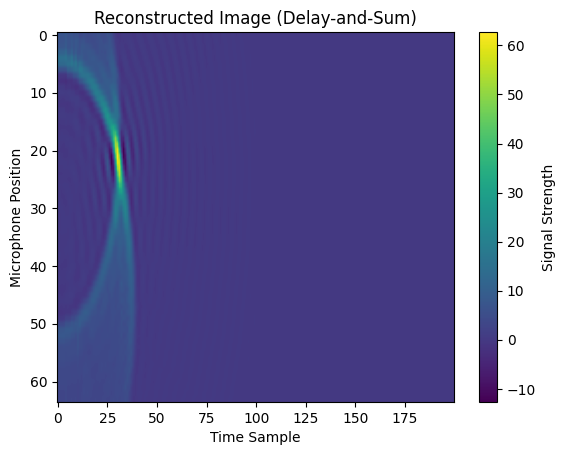

In [118]:
# Without limiting:
ri = DAS(Nmics, Nsamp, C, dist_per_samp, src, pitch, mic_positions, samples)
plt.imshow(ri, aspect = 'auto')
plt.colorbar(label='Signal Strength')
plt.xlabel('Time Sample')
plt.ylabel('Microphone Position')
plt.title('Reconstructed Image (Delay-and-Sum)')
plt.show()

### For Nsamp = 100

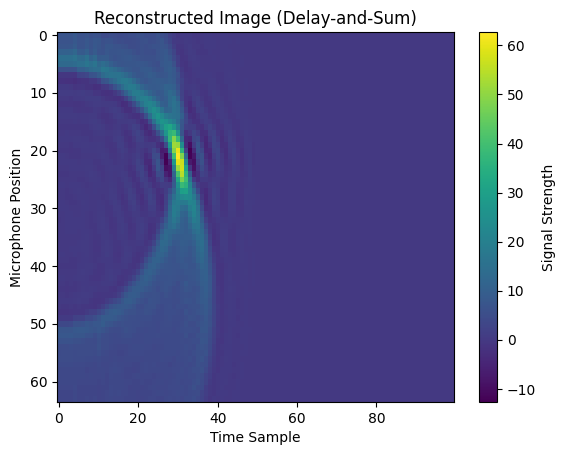

In [120]:
Nmics = 64
Nsamp = 100
src = (0, 0)
pitch = 0.1
dist_per_samp = 0.1
C = 2
SincP = 5
obstacle = (3,-1)

ri = final_reconstructed_image_computer(Nmics, pitch, dist_per_samp, Nsamp, src, obstacle, C, SincP)
plt.imshow(ri, aspect = 'auto')
plt.colorbar(label='Signal Strength')
plt.xlabel('Time Sample')
plt.ylabel('Microphone Position')
plt.title('Reconstructed Image (Delay-and-Sum)')
plt.show()


### Seeing how sincP affects the final reconstruction image

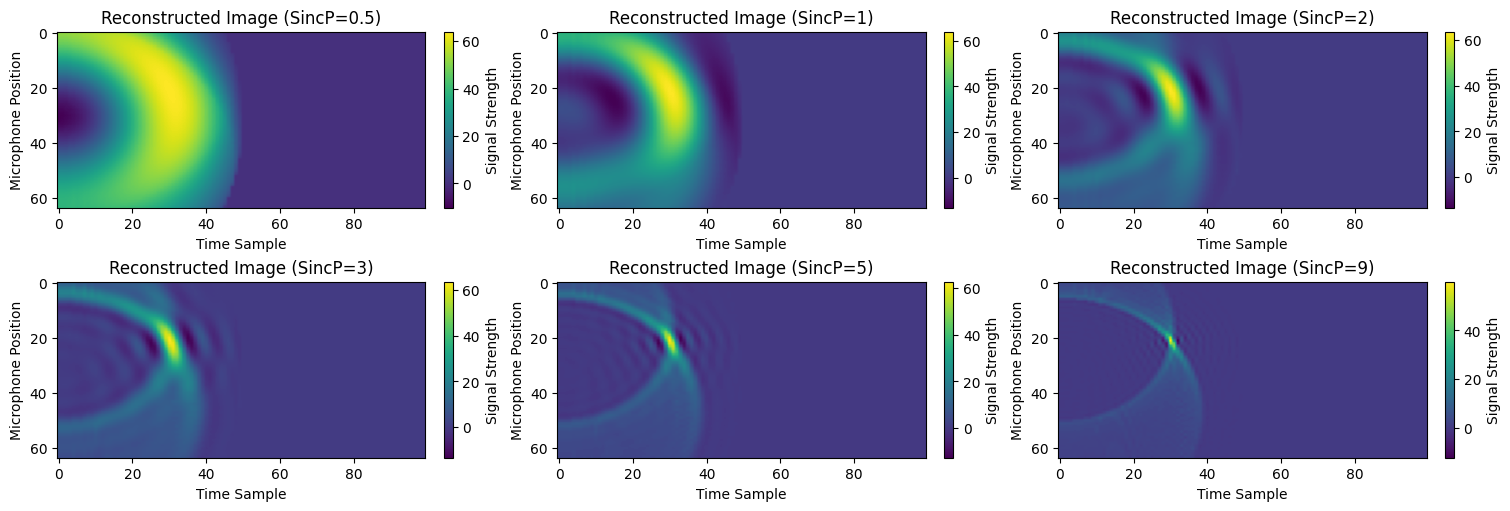

In [92]:
# The soud wave is wrsc
Nmics = 64           # Number of microphones
Nsamp = 100          # Number of samples
src = (0, 0)         # source location is taken at te origin
pitch = 0.1          # distance between consecutive microphones
dist_per_samp = 0.1  # distance between samples of the wave
C = 2                # speed of Sound wave
SincP = [0.5, 1, 2, 3, 5, 9]
obstacle = (3,-1)    #  Obstace location


# Constructing the final images for differentvalues of SincP:


fig, axes = plt.subplots(2, 3, figsize=(15, 5), constrained_layout = True)
axes = axes.flatten() # flatten as it is a 2d array
for idx, sincp in enumerate(SincP):
    ri = final_reconstructed_image_computer(Nmics, pitch, dist_per_samp, Nsamp, src, obstacle, C, sincp)
    im = axes[idx].imshow(ri, aspect='auto')
    fig.colorbar(im, ax=axes[idx], label='Signal Strength')
    axes[idx].set_xlabel('Time Sample')
    axes[idx].set_ylabel('Microphone Position')
    axes[idx].set_title(f'Reconstructed Image (SincP={sincp})')

# deleting unused axes
for idx in range(len(SincP), 6):
    fig.delaxes(axes[idx])
plt.show()





### Seeing how values of C affect the final image

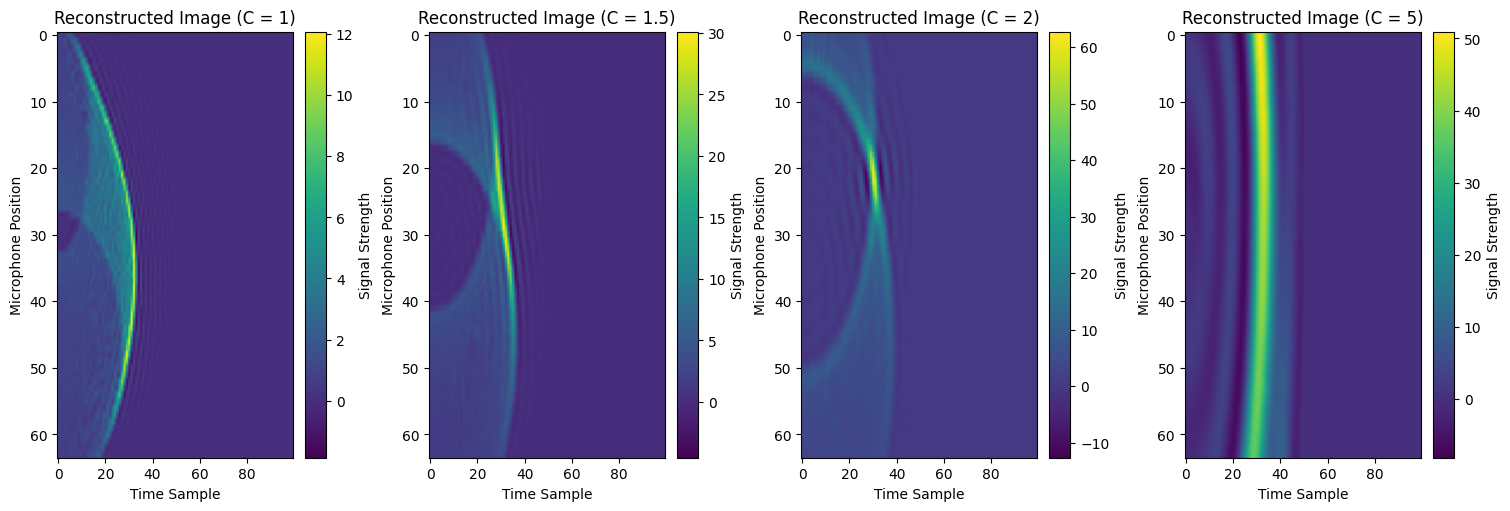

In [101]:
# Decreasing C

Nmics = 64
Nsamp = 100
src = (0, 0)
pitch = 0.1
dist_per_samp = 0.1
SincP = 5
obstacle = (3,-1)
C_val = [1, 1.5, 2, 5]


fig, axes = plt.subplots(1, 4, figsize=(15, 5), constrained_layout = True)
axes = axes.flatten() # flatten as it is a 2d array
for idx, C in enumerate(C_val):
    ri = final_reconstructed_image_computer(Nmics, pitch, dist_per_samp, Nsamp, src, obstacle, C, SincP)
    im = axes[idx].imshow(ri, aspect='auto')
    fig.colorbar(im, ax=axes[idx], label='Signal Strength')
    axes[idx].set_xlabel('Time Sample')
    axes[idx].set_ylabel('Microphone Position')
    axes[idx].set_title(f'Reconstructed Image (C = {C})')

plt.show()



# Testing out on other text files:

In [121]:
file = '/content/rx2.txt'
samples_2 = np.loadtxt(file)
print(samples_2, len(samples_2), len(samples_2[0]))

[[-0.046093 -0.044266 -0.024986 ...  0.000567  0.013285  0.020729]
 [-0.044968 -0.03069  -0.003858 ...  0.009416  0.018531  0.020415]
 [-0.034773 -0.01184   0.016546 ...  0.015522  0.019718  0.016299]
 ...
 [ 0.00242   0.00933   0.012971 ... -0.001077 -0.003778 -0.004998]
 [-0.003971  0.003423  0.009852 ...  0.00134  -0.001697 -0.004033]
 [-0.008777 -0.002969  0.004267 ...  0.003288  0.00063  -0.002214]] 64 200


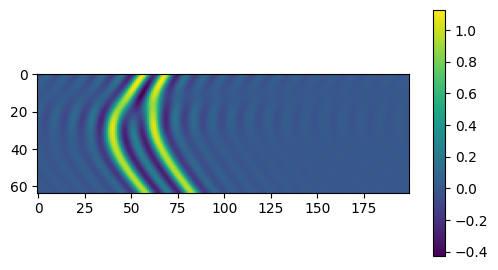

In [122]:
# Visualising the samples
fig = plt.figure(figsize=(6, 3.2))
plt.imshow(samples_2)
plt.colorbar(orientation='vertical')
plt.show()

In [123]:
ri = DAS(Nmics, Nsamp, C, dist_per_samp, src, pitch, mic_positions, list(samples_2))

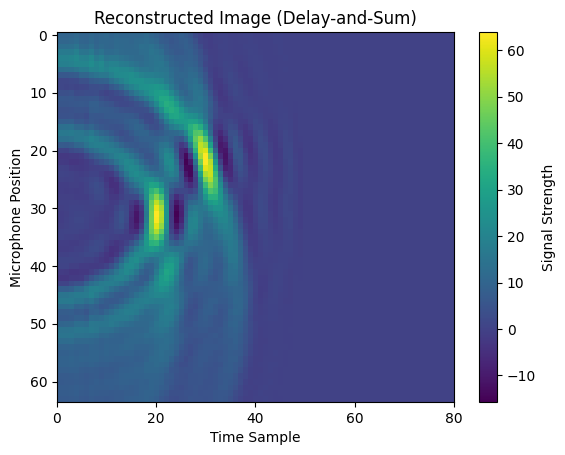

In [124]:

plt.imshow(ri, aspect = 'auto')
plt.xticks([0, 20, 40, 60, 80])
plt.xlim(0, 80)  # Limit x-axis to show values up to 80
plt.colorbar(label='Signal Strength')
plt.xlabel('Time Sample')
plt.ylabel('Microphone Position')
plt.title('Reconstructed Image (Delay-and-Sum)')
plt.show()

In [125]:
file = '/content/rx3.txt'
samples_3 = np.loadtxt(file)
print(samples_3, len(samples_3), len(samples_3[0]))

[[-0.040501 -0.03022  -0.007779 ...  0.01284   0.017685  0.015723]
 [-0.033295 -0.013816  0.011751 ...  0.016796  0.016613  0.010106]
 [-0.019023  0.004968  0.027881 ...  0.016894  0.011977  0.002573]
 ...
 [-0.015542 -0.003418  0.010536 ...  0.005621  0.009016  0.008892]
 [-0.021888 -0.012888  0.001549 ...  0.003526  0.0084    0.009973]
 [-0.02461  -0.021041 -0.009044 ...  0.000542  0.006767  0.010301]] 64 200


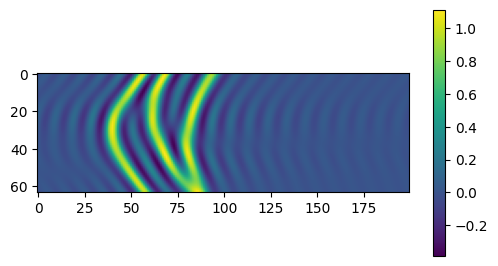

In [126]:
fig = plt.figure(figsize=(6, 3.2))
plt.imshow(samples_3)
plt.colorbar(orientation='vertical')
plt.show()

In [127]:
ri = DAS(Nmics, Nsamp, C, dist_per_samp, src, pitch, mic_positions, list(samples_3))

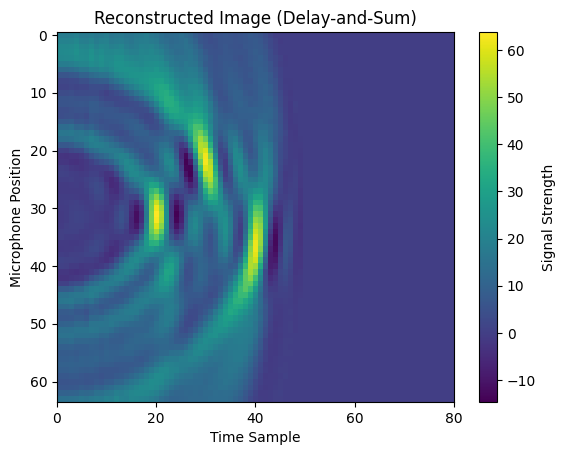

In [128]:

plt.imshow(ri, aspect = 'auto')
plt.xticks([0, 20, 40, 60, 80])
plt.xlim(0, 80)  # Limit x-axis to show values up to 80
plt.colorbar(label='Signal Strength')
plt.xlabel('Time Sample')
plt.ylabel('Microphone Position')
plt.title('Reconstructed Image (Delay-and-Sum)')
plt.show()

# Trying other values of Nmics and Nsamp

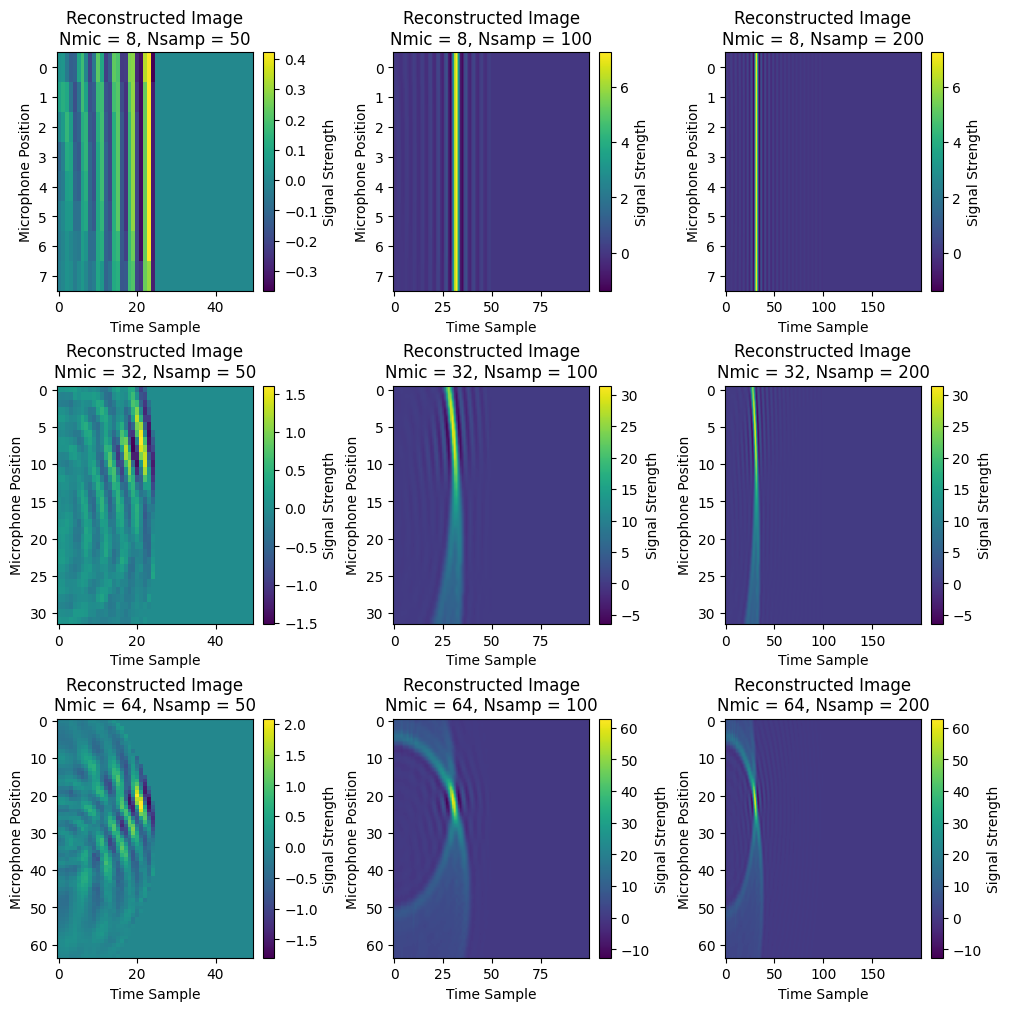

In [132]:
N_mics = [8,32, 64]
N_samp = [50,100,200]
fig, axes = plt.subplots(3, 3, figsize=(10, 10), constrained_layout=True)
axes = axes.flatten()  # Flatten to make indexing easier

for idx, nmics in enumerate(N_mics):
    for sub_idx, nsamp in enumerate(N_samp):
        ri = final_reconstructed_image_computer(nmics, pitch, dist_per_samp, nsamp, src, obstacle, C, SincP)
        ax = axes[idx * len(N_samp) + sub_idx]
        im = ax.imshow(ri, aspect='auto')
        fig.colorbar(im, ax=ax, label='Signal Strength')
        ax.set_xlabel('Time Sample')
        ax.set_ylabel('Microphone Position')
        ax.set_title(f'Reconstructed Image\nNmic = {nmics}, Nsamp = {nsamp}')

plt.show()

# Constructing images for different Obstacle positions:

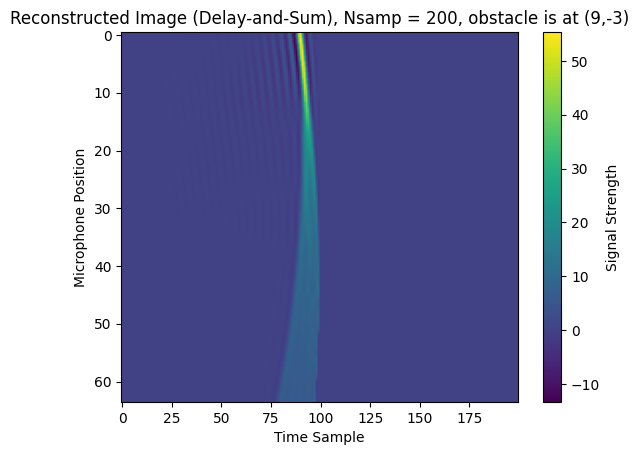

In [147]:
Nmics = 64
Nsamp = 200
src = (0, 0)
pitch = 0.1
dist_per_samp = 0.1
C = 2
SincP = 5
obstacle = (9,-3)

ri = final_reconstructed_image_computer(Nmics, pitch, dist_per_samp, Nsamp, src, obstacle, C, SincP)
plt.imshow(ri, aspect = 'auto')
plt.colorbar(label='Signal Strength')
plt.xlabel('Time Sample')
plt.ylabel('Microphone Position')
plt.title('Reconstructed Image (Delay-and-Sum), Nsamp = 200, obstacle is at (9,-3)')
plt.show()

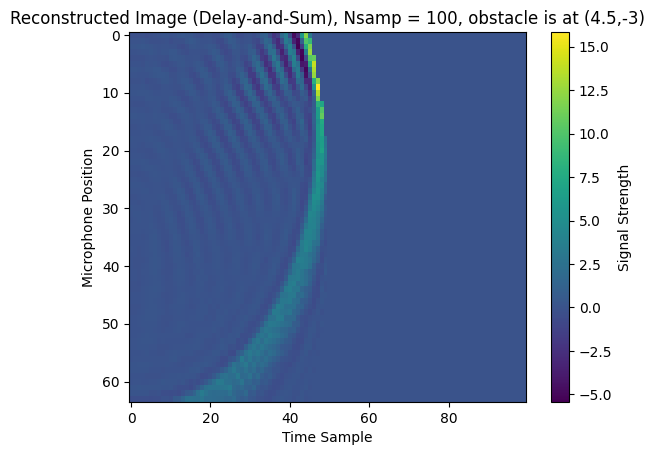

In [146]:
Nmics = 64
Nsamp = 100
src = (0, 0)
pitch = 0.1
dist_per_samp = 0.1
C = 2
SincP = 5
obstacle = (4.5,-3)

ri = final_reconstructed_image_computer(Nmics, pitch, dist_per_samp, Nsamp, src, obstacle, C, SincP)
plt.imshow(ri, aspect = 'auto')
plt.colorbar(label='Signal Strength')
plt.xlabel('Time Sample')
plt.ylabel('Microphone Position')
plt.title('Reconstructed Image (Delay-and-Sum), Nsamp = 100, obstacle is at (4.5,-3)')
plt.show()